# مكتشف الحواف , كاني:

### الهدف:

مفهوم مكتشف الحواف -كاني,
تابع التنفيذ الخاص به
`cv2.Canny`

## النظرية

مكتشف الحواف كاني , هو خوارزمية شائعة , ذات مراحل متعددة للتنفيذ وسنمر على كل مرحلة لها فيما يلي

1. **اولا - تخفيض الضجيج**

    بما ان اكتشاف الحواف , هو مسألة حساسة لضجيج الصورة , اول خطوة تكون بازالته وذلك بالمرشح الغاوسي  والذي رأيناه بالسابق

2. **ثانيا - ايجاد تدرج الشدة للصورة**

    الصور المنعمة تنعم بعدها وفق قناع 
    `sobel`
    العامودي والافقي , للحصول على التدرج الافقي والعامودي , ومن هاتين الصورتين يمكن معرفة ميل الحافة واتجاهها لكل بكسل كالتالي:

    $$Edge\_Gradient(G) = \sqrt{G_x^2 + G_y^2}$$
    $$Angle(\theta) = \tan^{-1}\left(\frac{G_y}{G_x}\right)$$
    
    واتجاه الميل دائما عمودي على الحافة , والزاوية تدور لقيمة من 4 تمثل الاتجاهات العامودية والافقية و2 قطرية

3. **ثالثا - الضغط اللااعظمي**

    بعد الحصول على التدرج والاتجاه , يتم اجراء مسح للصورة لحذف البكسلات الغير مشكلة للحافة , وذلك باكتشاف القيمة المحلية العظمى باتجاه المشتق عندها , فالنقطة تكون من الحافة فقط اذا كانت قيمة محلية عظمى بين النقاط بنفس اتجاه المشتق عندها وبذلك تمر للمرحلة التالية والا توضع صفراً , وبذلك نحصل على حواف ادق

4. **رابعاً - التعتيب الاعصاري**

    وفي هذه المرحلة نحدد ما اذا كانت الحواف حوافاً ام لا , ولذلك نأخذ قيمتين للعتبة , عظمى وصغرى , واذا كانت قيمة ميل الحافة أكبر من الحد الاعلى نعتبرها حافة اكيدة والا اذا كانت اقل من الحد الادنى لا نعتبرها حافة ونصفرها , وبالنسبة للقيم الوسطى نعتمد على اتصالها فيما اذا كان مع حافة اكيدة فنأخذها ام لا فنتركها.

    ولذلك يجب الاهتمام بأخذ حدود مناسبة وبالنهاية يتم هنا عملية ازالة للحواف القصيرة وما نحصل عليه اخيراً هو فقط الحواف القوية 


##  اكتشاف حواف كاني فيOpenCV :

كل الخوارزمية السابقة موجودة بتابع واحد وهو
`cv2.Canny`
ومتغيراته , الاول هو الصورة المراد اكتشاف حوافها/رمادية/والثاني والثالث هما حدا العتبة والرابع هو رقم صحيح لقياس قناع المكتشف
`sobel`
وافتراضياً هو 3والخامس  والاخير هو علم لاستخدام العلاقة السابقة لحساب الطويلة للتدرج او علاقة اقل دقة اخرى في حال كان 
`False`
وهي الحالة الافتراضية , كما التالي

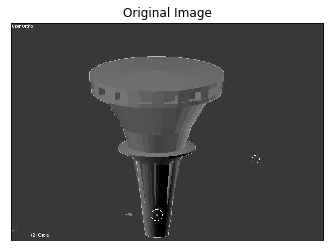

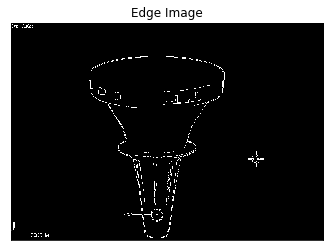

In [1]:
%matplotlib inline

import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('wt.jpg',0)

edges = cv2.Canny(img,100,200)

plt.imshow(img,cmap = 'gray')
plt.title('Original Image')
plt.xticks([]), plt.yticks([])
plt.show()

plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image')
plt.xticks([]), plt.yticks([])
plt.show()
None

## تمرين للحل: 
اكتب تطبيقا بسيطا يقوم بايجاد حواف كاني لصورة دخل  ويتم تحديد العتبتين له من خلال منزلقة يمكن تحريكها. وبهذه الطريقة يمكننا فهم اثر قيم العتبات على نتيجة الاكتشاف

### ملاحظة للتمارين
يمكنكم كتابة اقترحات للحل ادناه ضمن التعليقات , وسأحاول اقتراح الافضل او تحسين نوعية الاجوبة بالتفاعل مع حلولكم 